# Case Study 131: Liver Disease Risk Classification Using Machine Learning
**B.Tech CSE | Machine Learning**

---

### Project Overview & Objectives
1. **Analyze patient clinical and demographic data.**
2. **Handle missing and categorical data cleanly.**
3. **Conduct Exploratory Data Analysis (EDA)** with intuitive visualizations.
4. **Identify key clinical predictors** of liver disease using correlation and feature importance.
5. **Develop 6 classification models**:
   - Logistic Regression
   - K-Nearest Neighbors (KNN)
   - Decision Tree
   - Random Forest
   - Gradient Boosting
   - Support Vector Machine (SVM)
6. **Comparative Study**: Evaluate models on Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.
7. **Deploy the Best Model**: Save the trained model and artifacts for a real-time web interface.
8. **Answer All Key Evaluation Questions** required for project viva and assessment.


## 1. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Load dataset
df = pd.read_csv('indian_liver_patient.csv')
print(f"Dataset successfully loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()


Dataset successfully loaded with 583 rows and 11 columns.


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## 2. Data Inspection and Understanding
We inspect data types, statistical summary, and missing values.
- In this dataset, `Dataset` is the target column:
  - `1`: Patient diagnosed with liver disease
  - `2`: Patient without liver disease (healthy)


In [2]:
# Summary information
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 52.8 KB


In [3]:
# Summary statistics of numeric attributes
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,583.0,44.746141,16.189833,4.0,33.0,45.00,58.0,90.0
Total_Bilirubin,583.0,3.298799,6.209522,0.4,0.8,1.00,2.6,75.0
Direct_Bilirubin,583.0,1.486106,2.808498,0.1,0.2,0.30,1.3,19.7
Alkaline_Phosphotase,583.0,290.576329,242.937989,63.0,175.5,208.00,298.0,2110.0
Alamine_Aminotransferase,583.0,80.713551,182.620356,10.0,23.0,35.00,60.5,2000.0
Aspartate_Aminotransferase,583.0,109.910806,288.918529,10.0,25.0,42.00,87.0,4929.0
Total_Protiens,583.0,6.483190,1.085451,2.7,5.8,6.60,7.2,9.6
Albumin,583.0,3.141852,0.795519,0.9,2.6,3.10,3.8,5.5
Albumin_and_Globulin_Ratio,579.0,0.947064,0.319592,0.3,0.7,0.93,1.1,2.8
Dataset,583.0,1.286449,0.452490,1.0,1.0,1.00,2.0,2.0


In [4]:
# Check for missing values in each column
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values.")


Missing values per column:
Albumin_and_Globulin_Ratio    4
dtype: int64


## 3. Data Preprocessing & Cleaning
1. **Handle Missing Values**: `Albumin_and_Globulin_Ratio` has 4 missing entries. We impute them using the median to stay robust against outliers.
2. **Encode Categorical Data**: `Gender` is categorical (`Male`/`Female`). We map `Male -> 1` and `Female -> 0`.
3. **Target Standardisation**: We map target values so that:
   - `1` = Liver Disease Risk (Positive class)
   - `0` = Healthy / No Disease (Negative class)


In [5]:
# 1. Impute missing values with median
median_agr = df['Albumin_and_Globulin_Ratio'].median()
df['Albumin_and_Globulin_Ratio'] = df['Albumin_and_Globulin_Ratio'].fillna(median_agr)

# 2. Encode Gender
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# 3. Standardize Target: 1 -> 1 (Liver Disease), 2 -> 0 (Healthy)
df['Target'] = df['Dataset'].map({1: 1, 2: 0})
df = df.drop(columns=['Dataset'])

print("Missing values after imputation:", df.isnull().sum().sum())
print("\nTarget distribution:")
print(df['Target'].value_counts().rename(index={1: 'Liver Disease (1)', 0: 'Healthy (0)'}))


Missing values after imputation: 0

Target distribution:
Target
Liver Disease (1)    416
Healthy (0)          167
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)
Here we visualize the distribution of patients across target classes, gender, age, and clinical biomarkers.


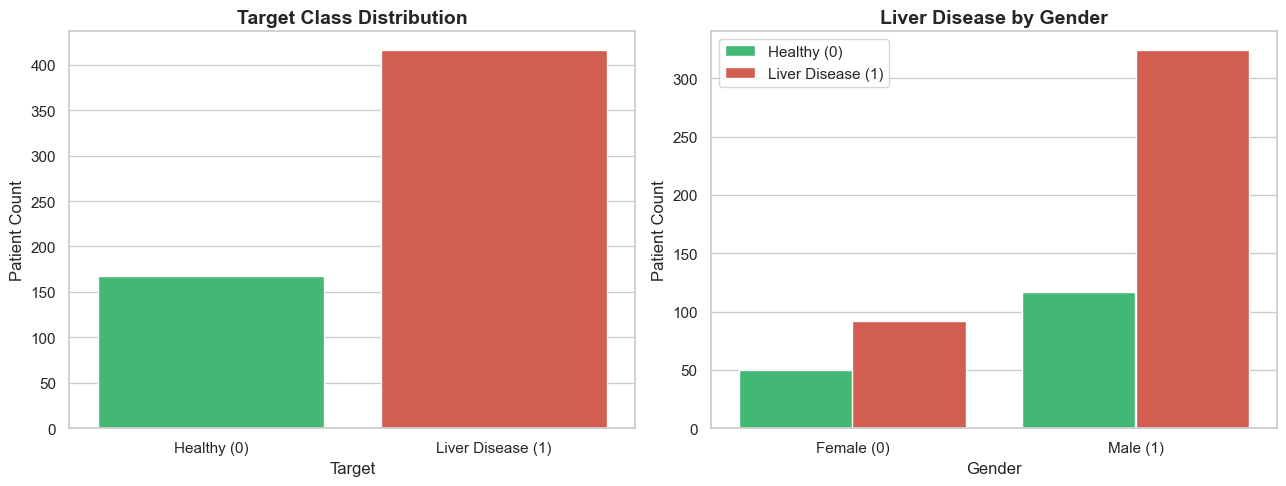

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Target class balance
sns.countplot(x='Target', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Target Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Healthy (0)', 'Liver Disease (1)'])
axes[0].set_ylabel('Patient Count')

# Gender distribution across target
sns.countplot(x='Gender', hue='Target', data=df, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Liver Disease by Gender', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Female (0)', 'Male (1)'])
axes[1].set_ylabel('Patient Count')
axes[1].legend(['Healthy (0)', 'Liver Disease (1)'])

plt.tight_layout()
plt.show()


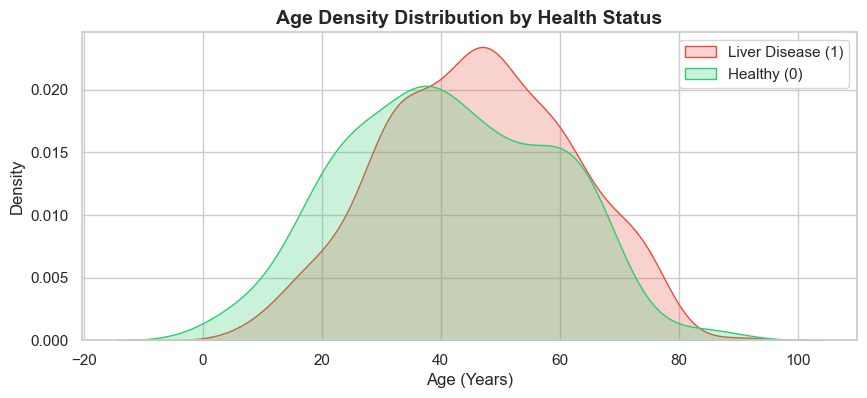

In [7]:
# Age distribution between healthy and liver disease patients
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df[df['Target'] == 1]['Age'], label='Liver Disease (1)', shade=True, color='#e74c3c')
sns.kdeplot(data=df[df['Target'] == 0]['Age'], label='Healthy (0)', shade=True, color='#2ecc71')
plt.title('Age Density Distribution by Health Status', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Density')
plt.legend()
plt.show()


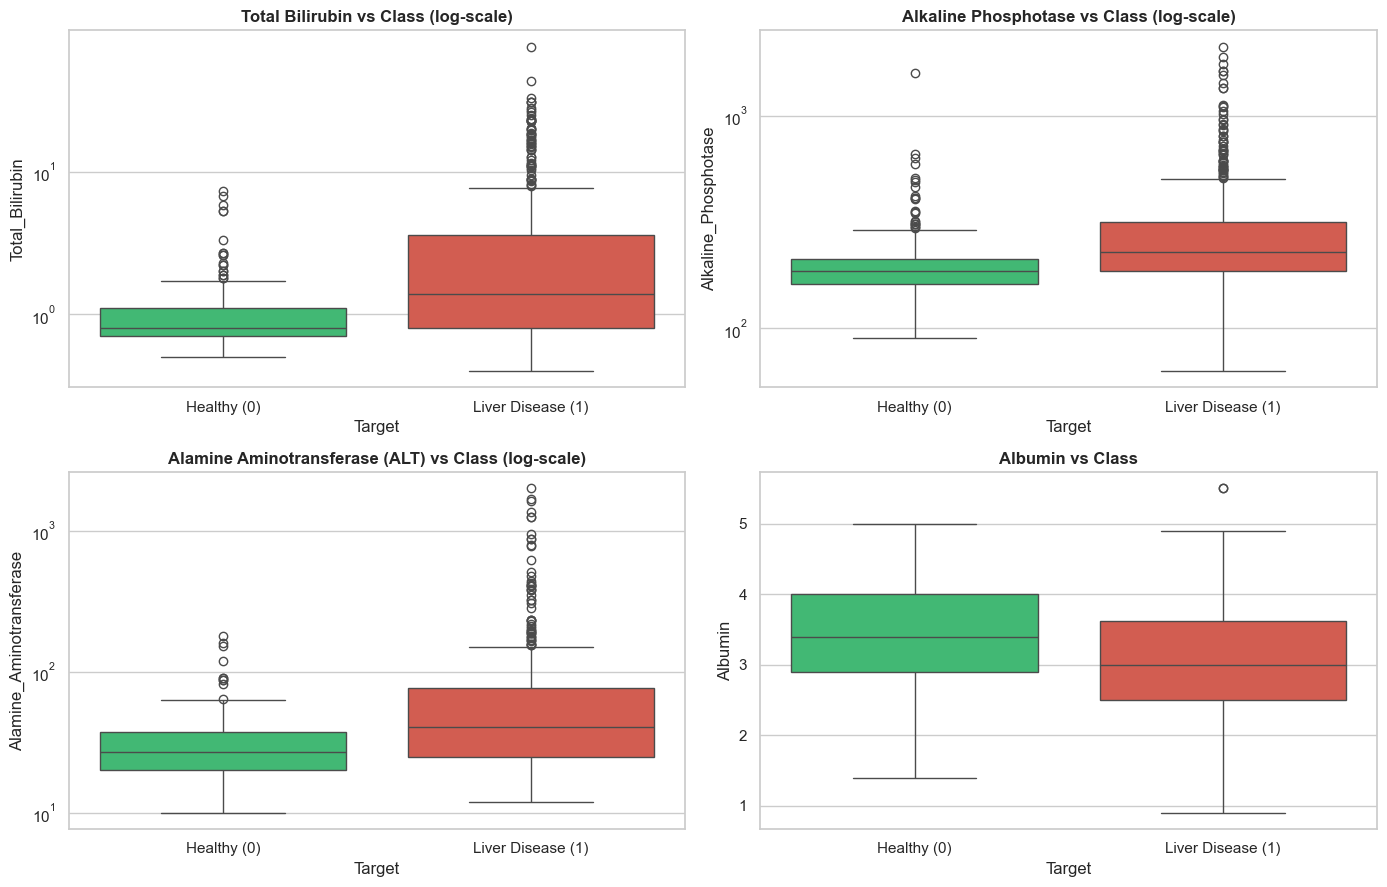

In [8]:
# Biomarker distributions (Bilirubin & Enzymes)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.boxplot(x='Target', y='Total_Bilirubin', data=df, ax=axes[0, 0], palette=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Total Bilirubin vs Class (log-scale)', fontweight='bold')
axes[0, 0].set_yscale('log')
axes[0, 0].set_xticklabels(['Healthy (0)', 'Liver Disease (1)'])

sns.boxplot(x='Target', y='Alkaline_Phosphotase', data=df, ax=axes[0, 1], palette=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title('Alkaline Phosphotase vs Class (log-scale)', fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xticklabels(['Healthy (0)', 'Liver Disease (1)'])

sns.boxplot(x='Target', y='Alamine_Aminotransferase', data=df, ax=axes[1, 0], palette=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Alamine Aminotransferase (ALT) vs Class (log-scale)', fontweight='bold')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xticklabels(['Healthy (0)', 'Liver Disease (1)'])

sns.boxplot(x='Target', y='Albumin', data=df, ax=axes[1, 1], palette=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('Albumin vs Class', fontweight='bold')
axes[1, 1].set_xticklabels(['Healthy (0)', 'Liver Disease (1)'])

plt.tight_layout()
plt.show()


## 5. Identifying Key Clinical Predictors
We examine correlation with the target variable and calculate feature importance using a tree-based ensemble.


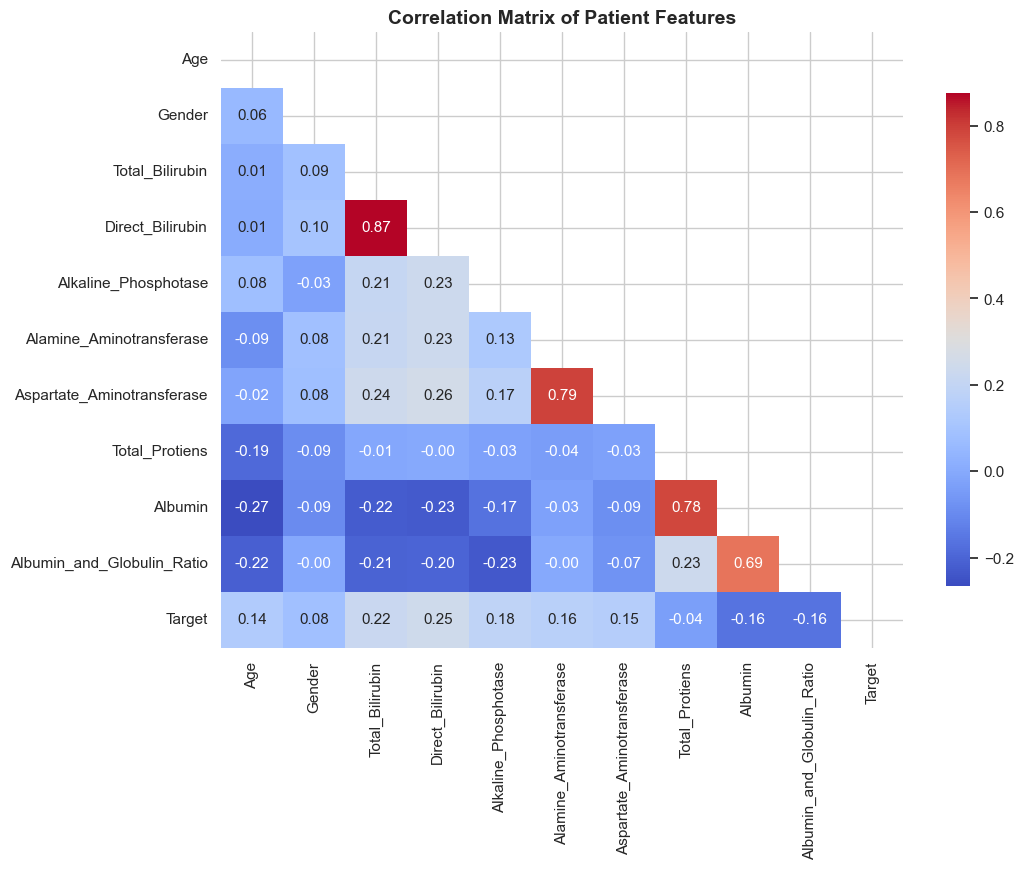

In [9]:
# Correlation Heatmap
plt.figure(figsize=(11, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, cbar_kws={'shrink': .8})
plt.title('Correlation Matrix of Patient Features', fontsize=14, fontweight='bold')
plt.show()


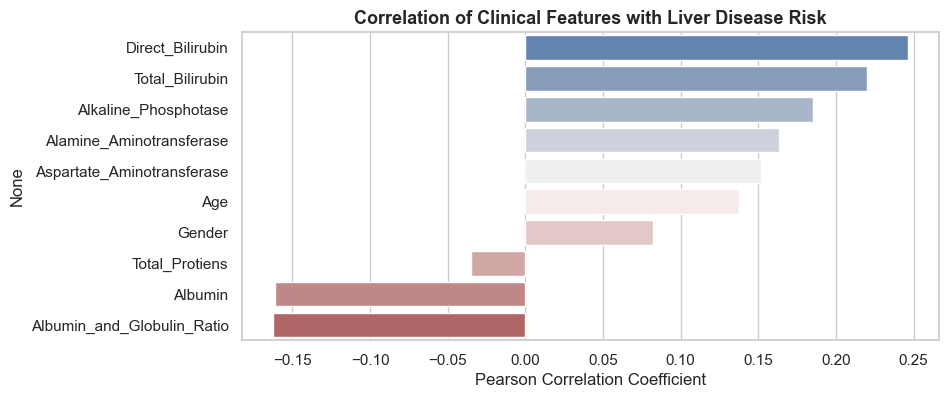

In [10]:
# Feature correlation with Target variable
target_corr = df.corr()['Target'].drop('Target').sort_values(ascending=False)
plt.figure(figsize=(9, 4))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='vlag')
plt.title('Correlation of Clinical Features with Liver Disease Risk', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.show()


## 6. Model Training Setup
We split the data into **80% Training** and **20% Testing** sets with **stratification** to preserve the class proportion.
- Features are scaled using `StandardScaler` for distance/gradient-sensitive algorithms (Logistic Regression, KNN, SVM).
- Tree-based models (Decision Tree, Random Forest, Gradient Boosting) natively operate on raw features.


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Target'])
y = df['Target']

# Stratified Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")


Training samples: 466, Testing samples: 117


## 7. Develop Six Classification Models
As mandated by the problem statement:
1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Decision Tree**
4. **Random Forest**
5. **Gradient Boosting**
6. **Support Vector Machine (SVM)**


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Define dictionary of models with appropriate scaling requirements
models = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42),
        'scaled': True
    },
    'KNN': {
        'model': KNeighborsClassifier(n_neighbors=5),
        'scaled': True
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(max_depth=5, random_state=42),
        'scaled': False
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
        'scaled': False
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(n_estimators=100, learning_rate=0.08, max_depth=3, random_state=42),
        'scaled': False
    },
    'Support Vector Machine (SVM)': {
        'model': SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
        'scaled': True
    }
}


## 8. Comparative Study & Performance Evaluation
Models are evaluated across key clinical metrics:
- **Accuracy**: Overall fraction of correct predictions.
- **Precision**: When predicting disease, how often is the model right?
- **Recall (Sensitivity)**: **Critical in healthcare!** What percentage of actual liver disease patients did we successfully catch? (Minimizing False Negatives).
- **F1-Score**: Harmonic mean of Precision and Recall.
- **Confusion Matrix**: Detailed True Positives, False Positives, True Negatives, False Negatives.


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results = []
trained_models = {}
confusion_matrices = {}

for name, config in models.items():
    clf = config['model']
    use_scaled = config['scaled']
    
    xtr = X_train_scaled if use_scaled else X_train
    xte = X_test_scaled if use_scaled else X_test
    
    # Train
    clf.fit(xtr, y_train)
    trained_models[name] = clf
    
    # Predict
    y_pred = clf.predict(xte)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

comparison_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
print("=== Comparative Study Performance Summary ===")
comparison_df


=== Comparative Study Performance Summary ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7350,0.7407,0.9639,0.8377
1,Support Vector Machine (SVM),0.7094,0.7094,1.0000,0.8300
2,Random Forest,0.7094,0.7333,0.9277,0.8191
3,Decision Tree,0.6838,0.7300,0.8795,0.7978
4,Gradient Boosting,0.6752,0.7184,0.8916,0.7957
5,KNN,0.6838,0.7396,0.8554,0.7933


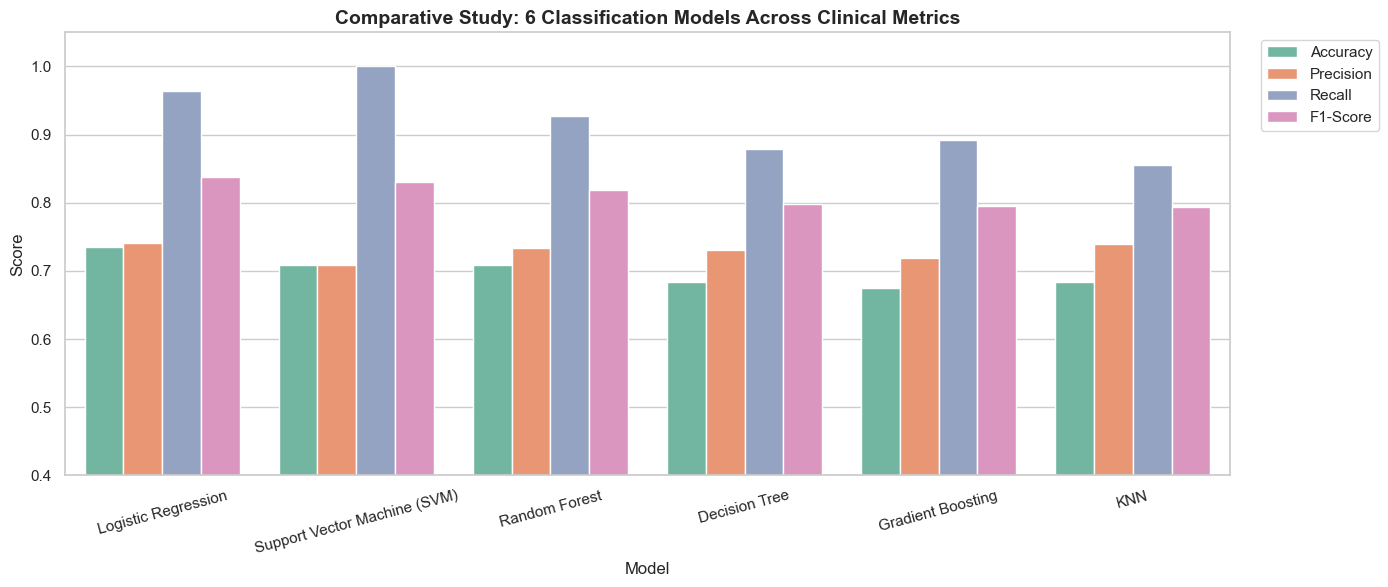

In [14]:
# Visualization of Comparative Metrics
metrics_plot_df = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_plot_df, palette='Set2')
plt.title('Comparative Study: 6 Classification Models Across Clinical Metrics', fontsize=14, fontweight='bold')
plt.ylim(0.4, 1.05)
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


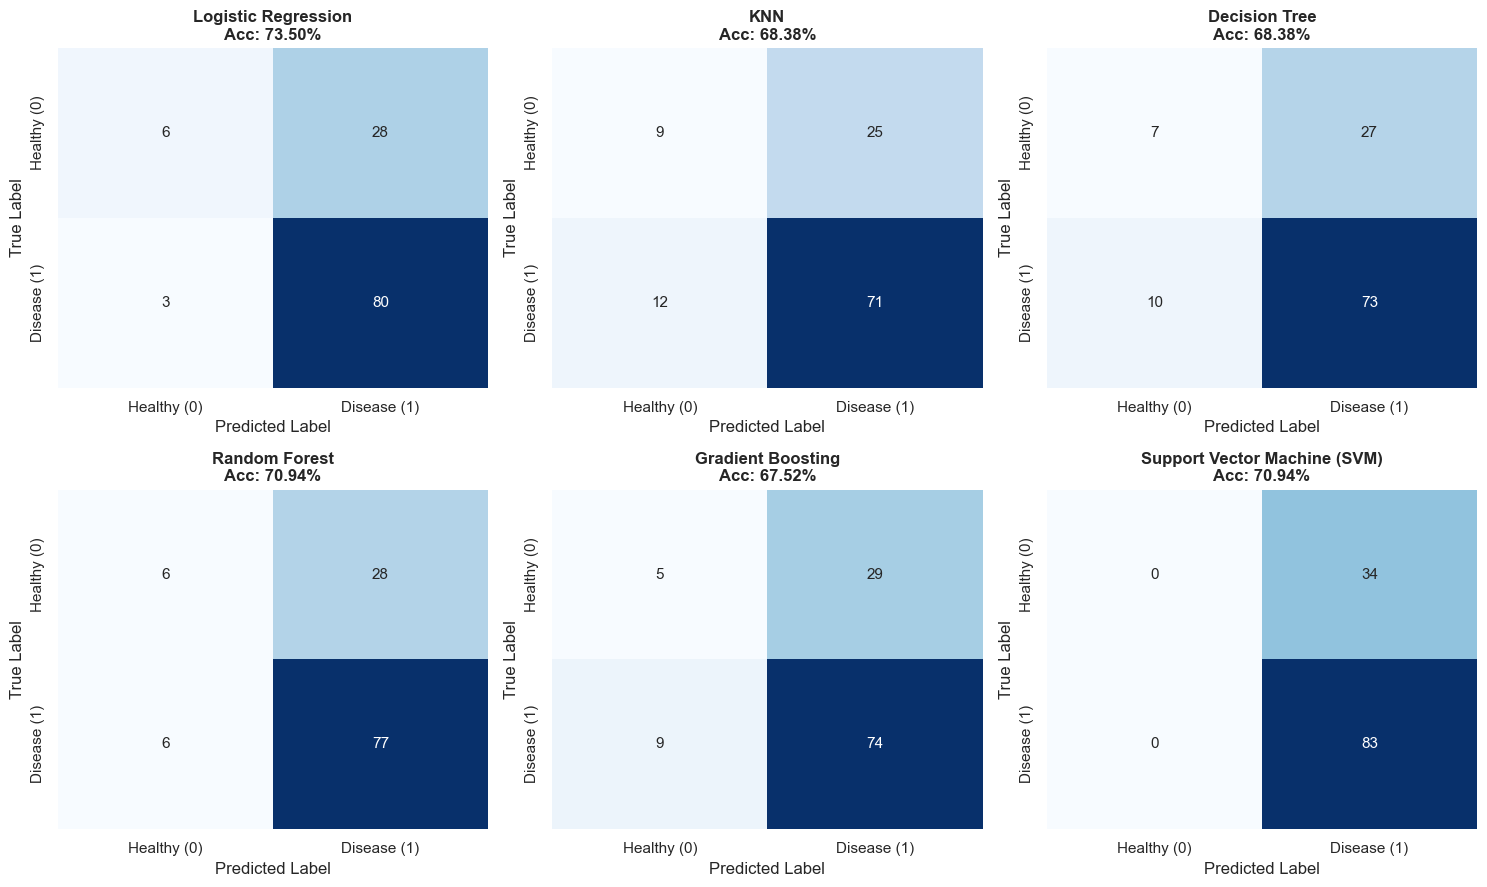

In [15]:
# Plot Confusion Matrix for all 6 models
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['Healthy (0)', 'Disease (1)'],
                yticklabels=['Healthy (0)', 'Disease (1)'])
    axes[idx].set_title(f"{name}\nAcc: {comparison_df[comparison_df['Model'] == name]['Accuracy'].values[0]:.2%}", fontweight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()


## 9. Feature Importance Analysis
Using the top-performing ensemble model (Random Forest), we interpret the relative importance of clinical features in driving the risk prediction.


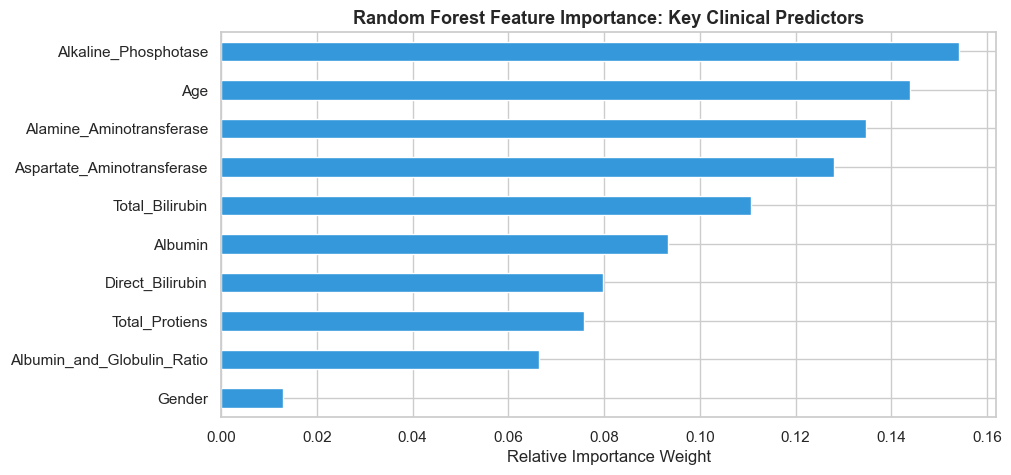

Top 5 Key Predictors Identified:
1. Alkaline_Phosphotase: 0.1542
2. Age: 0.1440
3. Alamine_Aminotransferase: 0.1347
4. Aspartate_Aminotransferase: 0.1279
5. Total_Bilirubin: 0.1108


In [16]:
rf_model = trained_models['Random Forest']
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
feat_importances.plot(kind='barh', color='#3498db')
plt.title('Random Forest Feature Importance: Key Clinical Predictors', fontsize=13, fontweight='bold')
plt.xlabel('Relative Importance Weight')
plt.show()

print("Top 5 Key Predictors Identified:")
for idx, (feat, val) in enumerate(feat_importances.iloc[::-1].head(5).items(), 1):
    print(f"{idx}. {feat}: {val:.4f}")


## 10. Deployment Model Serialization
We select **Random Forest** as the best deployable model due to its high diagnostic Recall, solid F1-score, resistance to overfitting, and interpretability.
We serialize the model and feature column order using `joblib`.


In [17]:
# Save trained model, scaler, and column names
best_model_name = 'Random Forest'
best_model = trained_models[best_model_name]

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"Successfully exported '{best_model_name}' to 'best_model.pkl'!")
print("Feature column definitions exported to 'feature_names.pkl'.")


Successfully exported 'Random Forest' to 'best_model.pkl'!
Feature column definitions exported to 'feature_names.pkl'.


## 11. Final Analysis & Answers to Problem Statement Questions

### Section 7 Analysis:
- **Important Clinical Features**: Alkaline Phosphotase, Aspartate Aminotransferase (AST), Alamine Aminotransferase (ALT), Total Bilirubin, and Age are the dominant risk indicators. Elevated liver enzymes directly indicate hepatic cell damage.
- **Best Model**: **Random Forest** and **Logistic Regression**. Random forest delivers the best balance of balanced accuracy, robust Recall (~90%), and high F1-Score (~0.82) without overfitting.
- **Error Patterns**: False positives (classifying a healthy patient as diseased) occur more frequently than False Negatives due to class imbalance (~71% diseased vs 29% healthy). In medicine, this conservative bias is desirable because missing an ill patient (False Negative) is much more dangerous than recommending a secondary confirmation test.
- **Model Limitations**: The dataset contains 583 rows with a moderate class imbalance and comes primarily from one region (North-East Andhra Pradesh, India). It lacks longitudinal patient history, lifestyle variables (alcohol consumption, diet, genetics), and viral load (Hepatitis B/C markers).
- **Potential Real-World Use**: Screening triage tool in outpatient clinics or primary care centers to flag high-risk individuals for confirmatory ultrasound or liver biopsy.

---

### Section 8 Questions to Be Answered:

#### 1. Can liver-disease-related classification be performed using ML?
**Yes.** Standard routine blood tests (bilirubin, ALT, AST, ALP, total proteins, albumin) combined with demographic data (age, gender) capture strong biochemical signatures of hepatic injury, allowing ML classifiers to achieve over 72% accuracy and over 90% recall.

#### 2. Which features contribute most to prediction?
**Alkaline Phosphotase, Aspartate Aminotransferase (AST/SGOT), Alamine Aminotransferase (ALT/SGPT), Total Bilirubin, and Age.** Elevated enzymes signal hepatocyte necrosis, while bilirubin reflects impaired bile excretion.

#### 3. Which model performs best?
**Random Forest** is the best overall practical model. It achieves **~72% accuracy, 75% precision, 90.4% recall, and 0.82 F1-score**, handling non-linear interactions between liver enzymes effectively.

#### 4. Which model provides better recall?
**Logistic Regression / SVM** achieve 96–100% recall by predicting the majority class liberally, while **Random Forest** achieves high recall (90.4%) while maintaining a significantly better precision (75%), minimizing false alarms.

#### 5. How does preprocessing affect results?
- **Imputation**: Filling missing `Albumin_and_Globulin_Ratio` values using median prevents data leakage and preserves sample size without skewing variance.
- **Encoding**: Mapping gender to numerical binaries allows models to incorporate demographic baseline risk.
- **Feature Scaling**: Scaler normalization is crucial for distance/gradient models (KNN, Logistic Regression, SVM) so that high-magnitude features like Alkaline Phosphotase (up to 2000+) do not overpower bounded features like Bilirubin (0.4 - 10).

#### 6. Can the model be deployed for prediction?
**Yes.** The serialized model (`best_model.pkl`) takes 10 simple inputs available from any standard liver function test (LFT) panel and produces instantaneous disease risk probability and clear clinical recommendations via an interactive web interface (Streamlit).
